Questions for TAs:
* Question 1.1: What does it mean "expected accuracy = [1.0]". Should I get that if I iterate over multiple seeds?
* Question 1.1: (and in general): Is it okay if I set the random states and do it over multiple seeds?
* Question 2.1: Inconsistency with voting_with_missing dataset. Says attribute 2 has no unknown even though there is.
* Question 2.1: Already set up for na/? values? I don't think there is actually anything I have to change. Should I just say that in the discussion?


# Decision Tree Lab

In [196]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.model_selection import train_test_split

In [197]:
# Load all data for lab
# iris data
!curl -O https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff
# voting_with_missing data
!curl -O https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/voting_with_missing.arff
# cars data
!curl -O https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/cars.arff


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  7485  100  7485    0     0  46278      0 --:--:-- --:--:-- --:--:-- 46490
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 40261  100 40261    0     0   233k      0 --:--:-- --:--:-- --:--:--  234k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 55386  100 55386    0     0   294k      0 --:--:-- --:--:-- --:--:--  293k


## 1 Debug and Eval

### 1.1 (5%) Debug 

- Train a DecisionTreeClassifier on the [Iris Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff) using all default parameters.
- If using Dataframes you may want to change the class values from bytecodes to strings with
iris_df['class'] = iris_df['class'].str.decode('utf-8') 

Expected Accuracy = [1.0]


,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


Accuracy on test data: 1.0


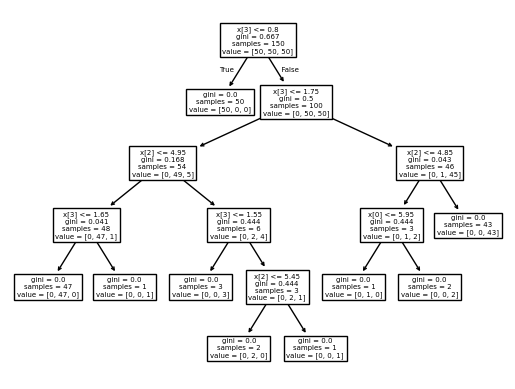

In [198]:
#Debug
# Load dataset, put it in a dataframe, and display
iris, meta = arff.loadarff('iris.arff')
iris_df = pd.DataFrame(iris)

# Change the class values from bytecodes to strings
iris_df['class'] = iris_df['class'].str.decode('utf-8') 
display(iris_df)
X = iris_df.drop(columns="class")
y = iris_df['class']

iris_DTC = DecisionTreeClassifier()
iris_DTC.fit(X, y)

# Test the decision tree classifier
print("Accuracy on test data:", iris_DTC.score(X, y))
plot_tree(iris_DTC)
plt.show()

### 1.2 (5%) Evaluation 

- Train on the iris data set again but this time with max_depth = 3 and output the accuracy

Accuracy on test data with max_depth=3: 0.9733333333333334


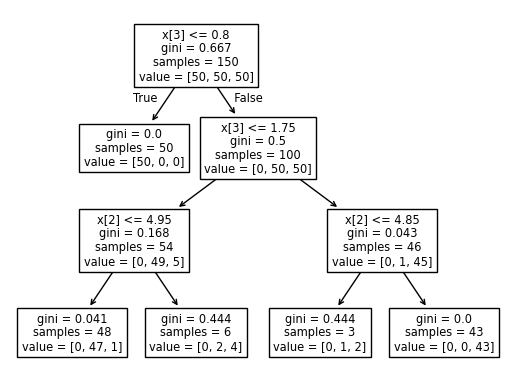

In [199]:
# Test over 20 different random seeds
accuracy = []
# Create and fit a decision tree classifier with max_depth=3
iris_DTC_depth_3 = DecisionTreeClassifier(max_depth=3)
iris_DTC_depth_3.fit(X, y)

# Test the decision tree classifier
print("Accuracy on test data with max_depth=3:", iris_DTC_depth_3.score(X, y))
plot_tree(iris_DTC_depth_3)
plt.show()

#### Discussion
What did you see? What were the differences in accuracy between the two trained models? How do you account for the differences or no differences? 

**The original model achieved a test accuracy of 100% and the model with max_depth=3 achieved a test accuracy of 97.33%.  This difference in test accuracies can be attributed to the fact that the original model was able to continuously split the tree until all points were correctly identified while the model with max_depth=3 was not able to train on the data to that same extent. However, since nearly all of the data points can be classified after 3 splits, as seen in the second tree, the tree with max_depth=3 still did very well overall.  It is possible that if a train and test split were introduced, we would see that the first model overfit to the data.**

## 2. Missing Values, N-fold CV, and Decision Tree Items  

### 2.1 (15%) Handling missing values
- Use this [Voting Dataset with missing values](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/voting_with_missing.arff)
- This data set has missing data.  Create an extra feature value for each feature with missing data. For example, if the feature were color with possible values R, G, B, you would add a fourth value (e.g. U or ? for unknown).
- Do not use a stopping criteria. Induce the tree as far as it can go (until classes are pure or there are no more data or attributes to split on).
- SKlearn does not allow nominal features, which initially seems odd. However, SKlearn uses the binary CART algorithm where a nominal data value like color is broken down into blue or not blue, red or not red, etc.  It is thus natural to just use one-hot encoding for each nominal feature.
- Use an 80/20 train/test split.
- Report the training and test set accuracies.

New dataset attributes:
['n' 'u' 'y']
['y' 'n' 'u']
['n' 'y' 'u']
['y' 'u' 'n']
['y' 'u' 'n']
['y' 'n' 'u']
['n' 'y' 'u']
['n' 'y' 'u']
['n' 'y' 'u']
['y' 'n' 'u']
['u' 'n' 'y']
['y' 'n' 'u']
['y' 'u' 'n']
['y' 'n' 'u']
['n' 'y' 'u']
['y' 'u' 'n']
['republican' 'democrat']
Training accuracy:  1.0
Test accuracy:  0.9540229885057471


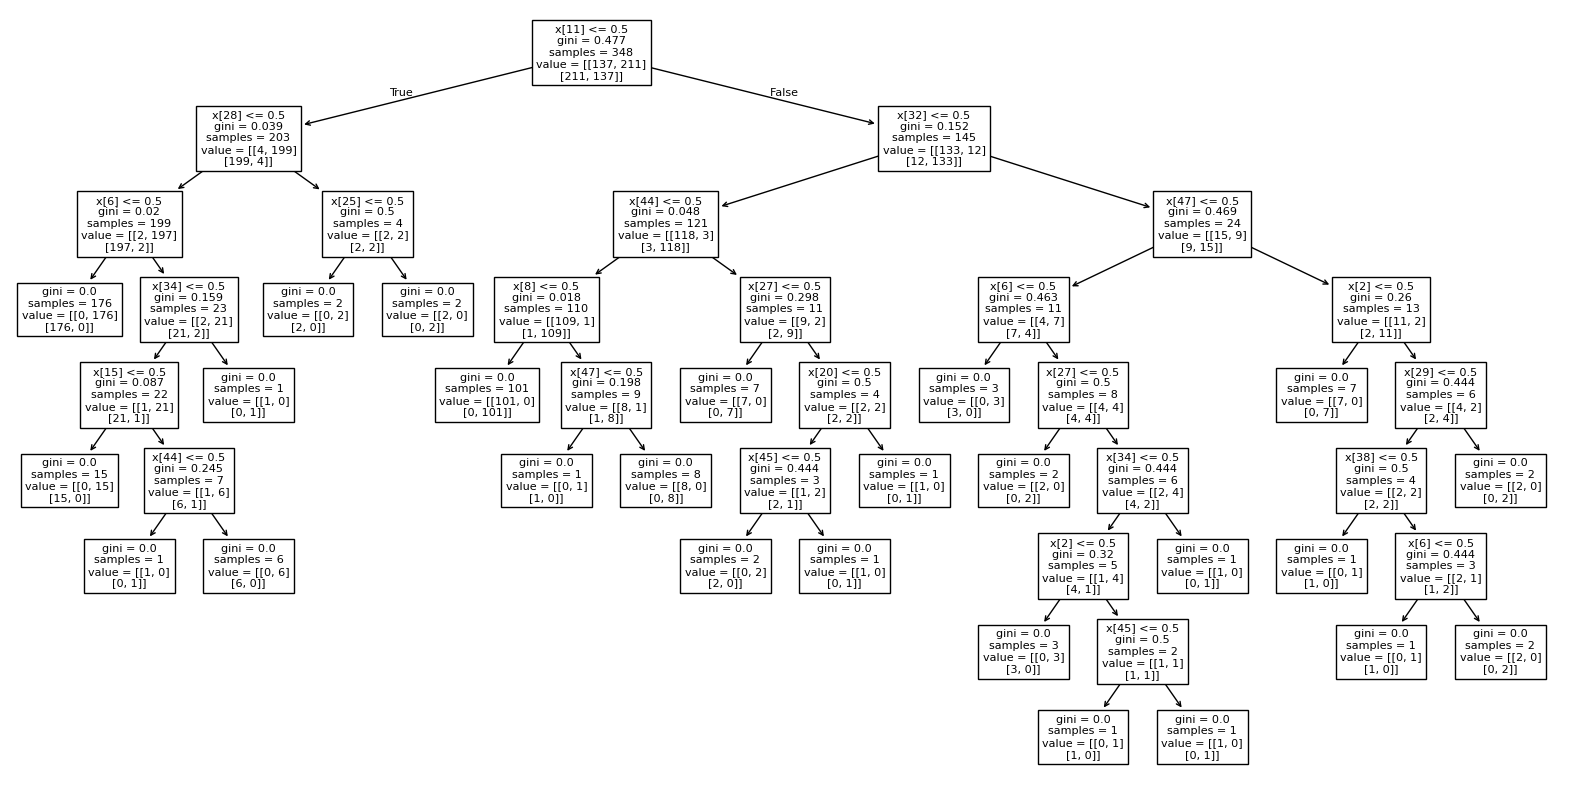

In [209]:
# Load voting_with_missing values and make all values strings
voting, meta = arff.loadarff('voting_with_missing.arff')
voting_df = pd.DataFrame(voting)
print("New dataset attributes:")
for feature in voting_df.columns:
    voting_df[feature] = voting_df[feature].str.decode('utf-8') 
    voting_df[feature] = voting_df[feature].replace('?', "u") # Replace missing values with "u"
    print(voting_df[feature].unique())

# Set up data using one-hot encoding and a 80/20 split
X = pd.get_dummies(voting_df.drop(columns="Class"))
y = pd.get_dummies(voting_df["Class"])
X_train_voting, X_test_voting, y_train_voting, y_test_voting = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize, fit, and plot tree
votingDTC = DecisionTreeClassifier(random_state=42)
votingDTC.fit(X_train_voting, y_train_voting)

# Report training and test accuracies
print("Training accuracy: ", votingDTC.score(X_train_voting, y_train_voting))
print("Test accuracy: ", votingDTC.score(X_test_voting, y_test_voting))

# Plot it to show there is no stopping criteria
plt.figure(figsize=(20, 10))
plot_tree(votingDTC)
plt.show()


#### Discussion
Report on your accuracies and include explaining how the missing values were handled by your model

**With my model I got a training accuracy of 100% and a test accuracy of 95.40%.  This indicates that the model is overfitting to the train data which makes sense since the tree has no limit to its depth.  The dataset already had "?" to represent each of the missing values.  All I had to do was make each one a string, replace each "?" value with a "u" and perform one-hot encoding on each feature so that each attribute (including if the attribute was missing) could be analyzed properly.  If the dataset had included "?" with other attributes like "Nan" or "unknown", I could replace each one with the proper attribute value to get the desired outcome.**

### 2.2 (15%)  N-fold Cross Validation
- Learn the [Cars Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/cars.arff) with the decision tree.
- Create a table with the 10-fold cross validation accuracies and show the average predicted accuracy.
- Try it again with 5-fold CV and create and show that table also.

In [211]:
from sklearn.model_selection import cross_val_score, cross_validate, KFold

# Load the data
cars, meta = arff.loadarff("cars.arff")
cars_df = pd.DataFrame(cars)
for feature in cars_df.columns:
    cars_df[feature] = cars_df[feature].str.decode('utf-8') 

# Set up data
X_cars = pd.get_dummies(cars_df.drop(columns="class"))
y_cars = cars_df["class"]

# Use 10-fold cross validation
carsDTC = DecisionTreeClassifier(random_state=42)
kf = KFold(n_splits = 10, shuffle=True, random_state=42)
cars_results = cross_validate(carsDTC, X_cars, y_cars, cv=kf)

results_df = pd.DataFrame(cars_results["test_score"])
results_df = results_df.rename({0: "10-Fold Accuracies"}, axis=1)
display(results_df)
print("10-Fold average predicted accuracy: ", np.mean(results_df))

# Use 5-fold cross validation
carsDTC = DecisionTreeClassifier(random_state=42)
kf = KFold(n_splits = 5, shuffle=True, random_state=42)
cars_results = cross_validate(carsDTC, X_cars, y_cars, cv=kf)

results_df = pd.DataFrame(cars_results["test_score"])
results_df = results_df.rename({0: "5-Fold Accuracies"}, axis=1)
display(results_df)
print("5-Fold average predicted accuracy: ", np.mean(results_df))



,10-Fold Accuracies
0,0.953757
1,0.976879
2,0.953757
3,0.971098
4,0.971098
5,0.988439
6,0.965318
7,0.982659
8,0.970930
9,0.959302


10-Fold average predicted accuracy:  0.9693238338486356


,5-Fold Accuracies
0,0.956647
1,0.971098
2,0.976879
3,0.959420
4,0.968116


5-Fold average predicted accuracy:  0.966432101868141


#### Discussion
Explain n-fold cross validation. Why do we do it? How is it useful? What does it reveal? Do we end up with a model? If so, which one? 

**n-fold cross validation is used to help you compare two or more different types of models as well as help determine what hyperparameters for a model make it perform best on a dataset. It is a way to test a model to determine how consistently it performs with varying train and test data by splitting up the data into n different groups and iteratively training the model on all but one of the groups, afterwhich the last group is used as an example validation set. With cross validation a final model is not returned directly as the purpose is more for evaluating two or more different models and determining which one is best, as seen through the resulting average predicted accuracy of each model tested.**

### 2.3 (10%) Decision Tree Intuition
For each of the two problems above (Voting and Cars):
- Print the full tree for each.  You may use tree.plot_tree(clf) or [another way](https://mljar.com/blog/visualize-decision-tree/) if you prefer.  tree.plot_tree has a number of parameters which you can try which let you print more informative trees which can help your discussion.
- Train both again with max_depth = 2 and print these smaller trees and include them in your report.
- Summarize in English what these 2 smaller decision trees have learned (i.e. look at the induced trees and describe what "rules" they discovered). 
- Compare your thoughts on important features with the attribute feature_importances_

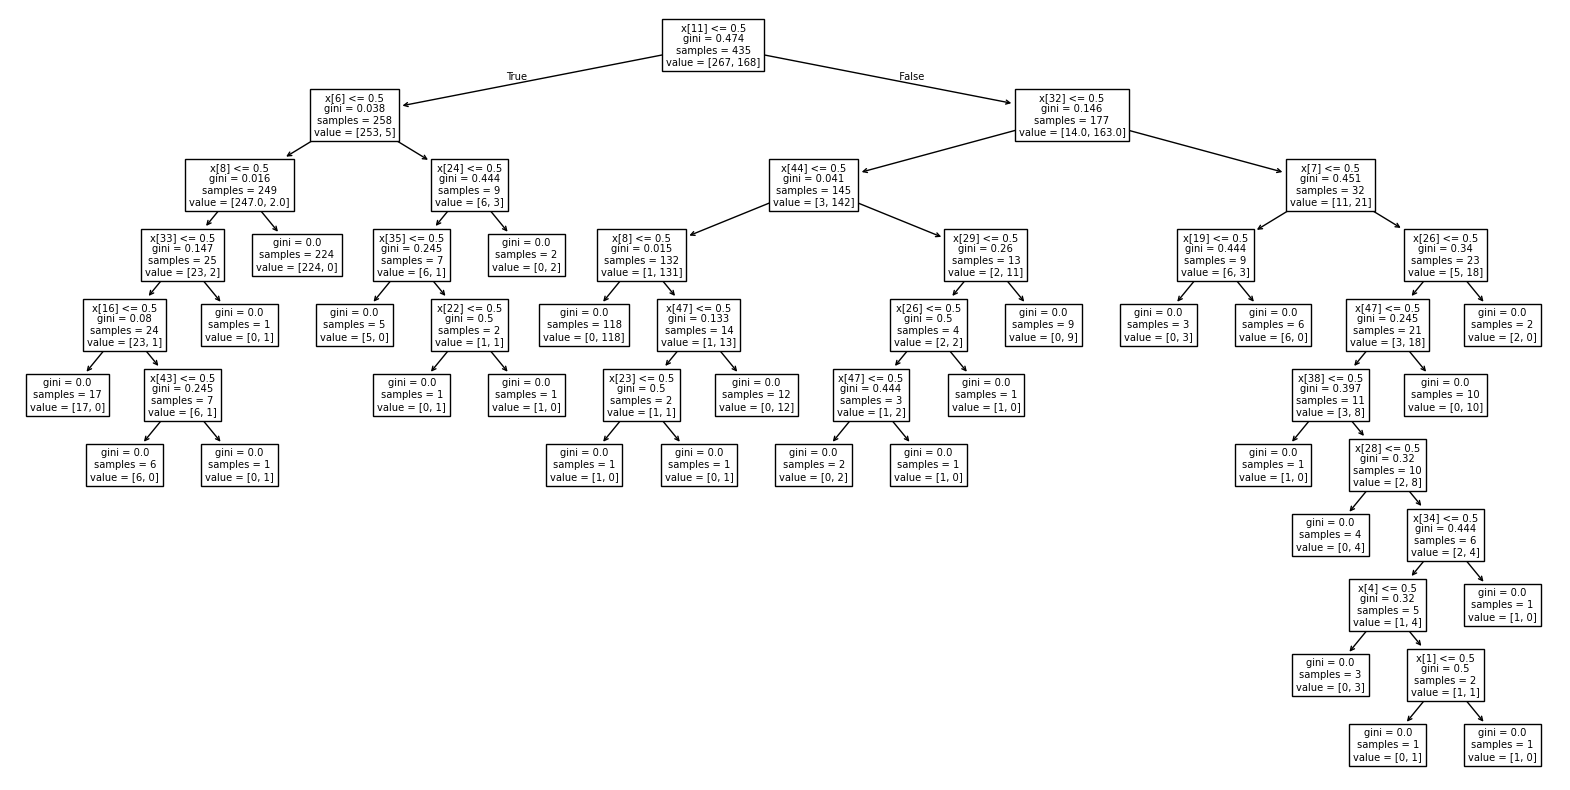

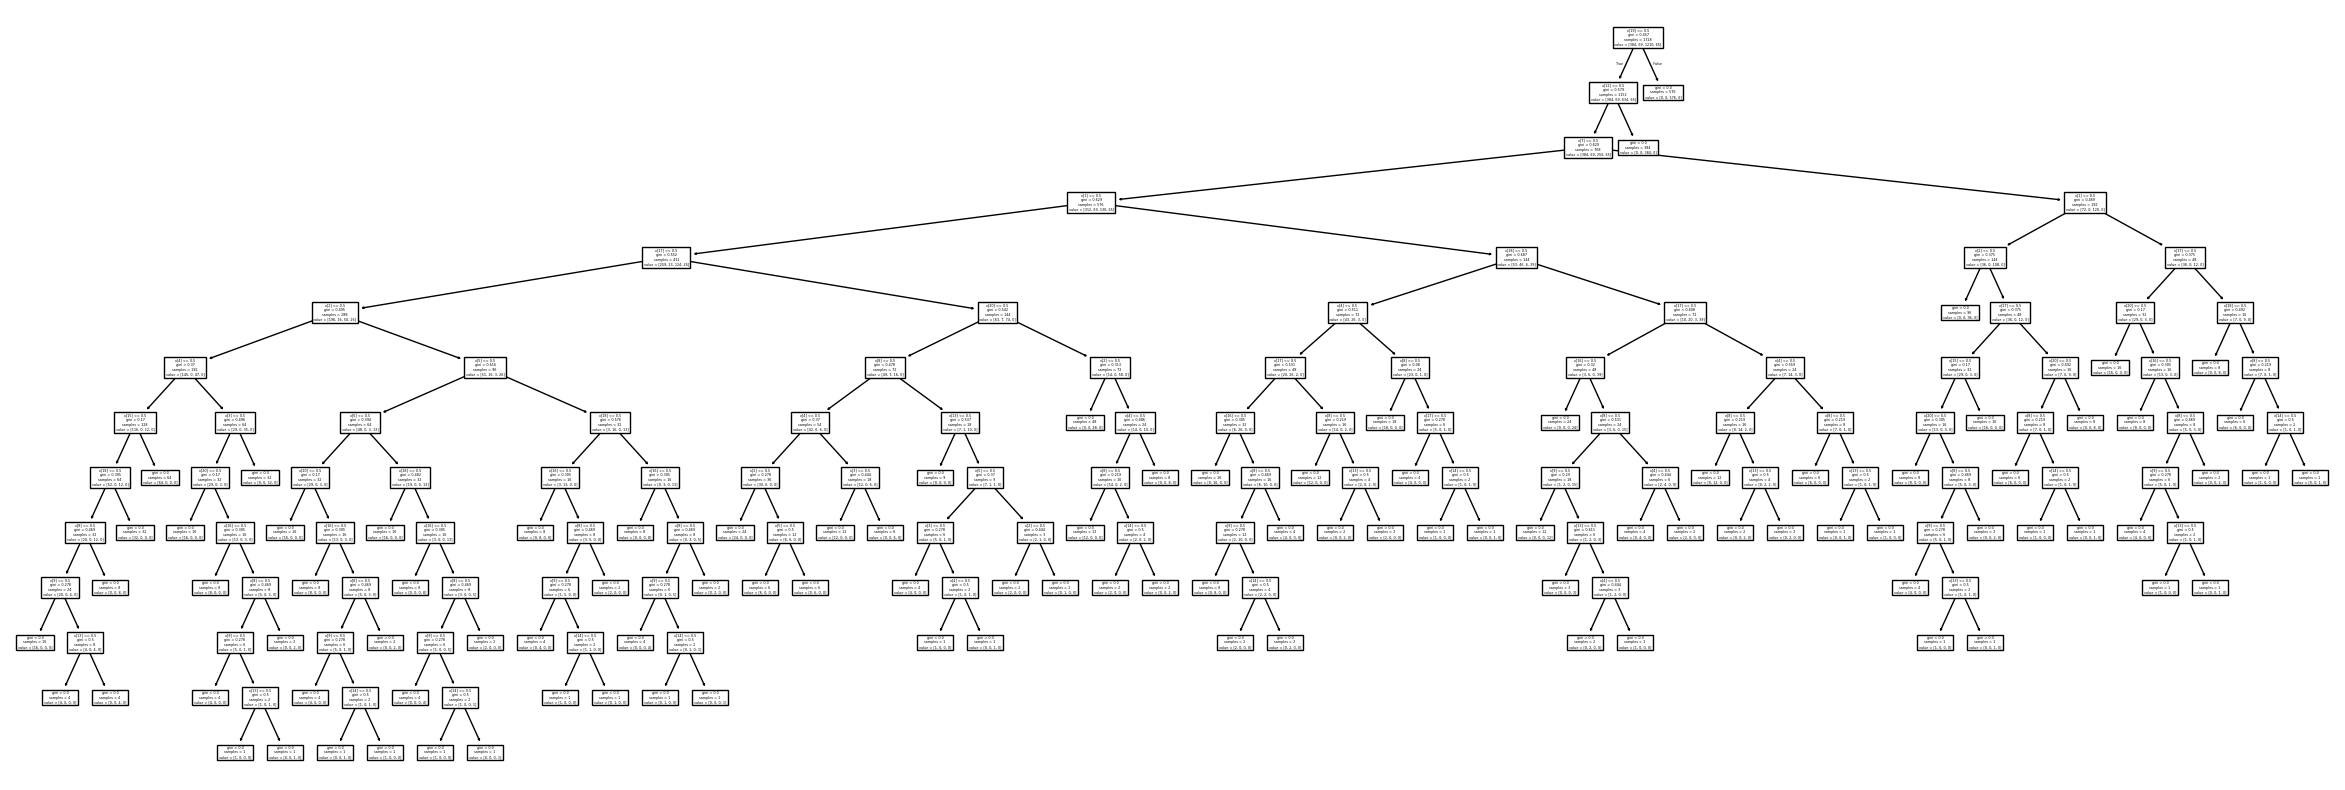

Full tree voting feature importances: 
                                     Feature  Importance
11                    physician-fee-freeze_y    0.827422
32            synfuels-corporation-cutback_y    0.026533
19                 anti-satellite-test-ban_n    0.019395
26                              mx-missile_y    0.016243
47  export-administration-act-south-africa_y    0.014400
7        adoption-of-the-budget-resolution_n    0.012662
24                              mx-missile_?    0.011083
6        adoption-of-the-budget-resolution_?    0.008914
33                      education-spending_?    0.008550
43                       duty-free-exports_n    0.008312
29                             immigration_y    0.006714
38                  superfund-right-to-sue_y    0.005642
34                      education-spending_n    0.005172
22               aid-to-nicaraguan-contras_n    0.004849
1                      handicapped-infants_n    0.004849
23               aid-to-nicaraguan-contras_y    0

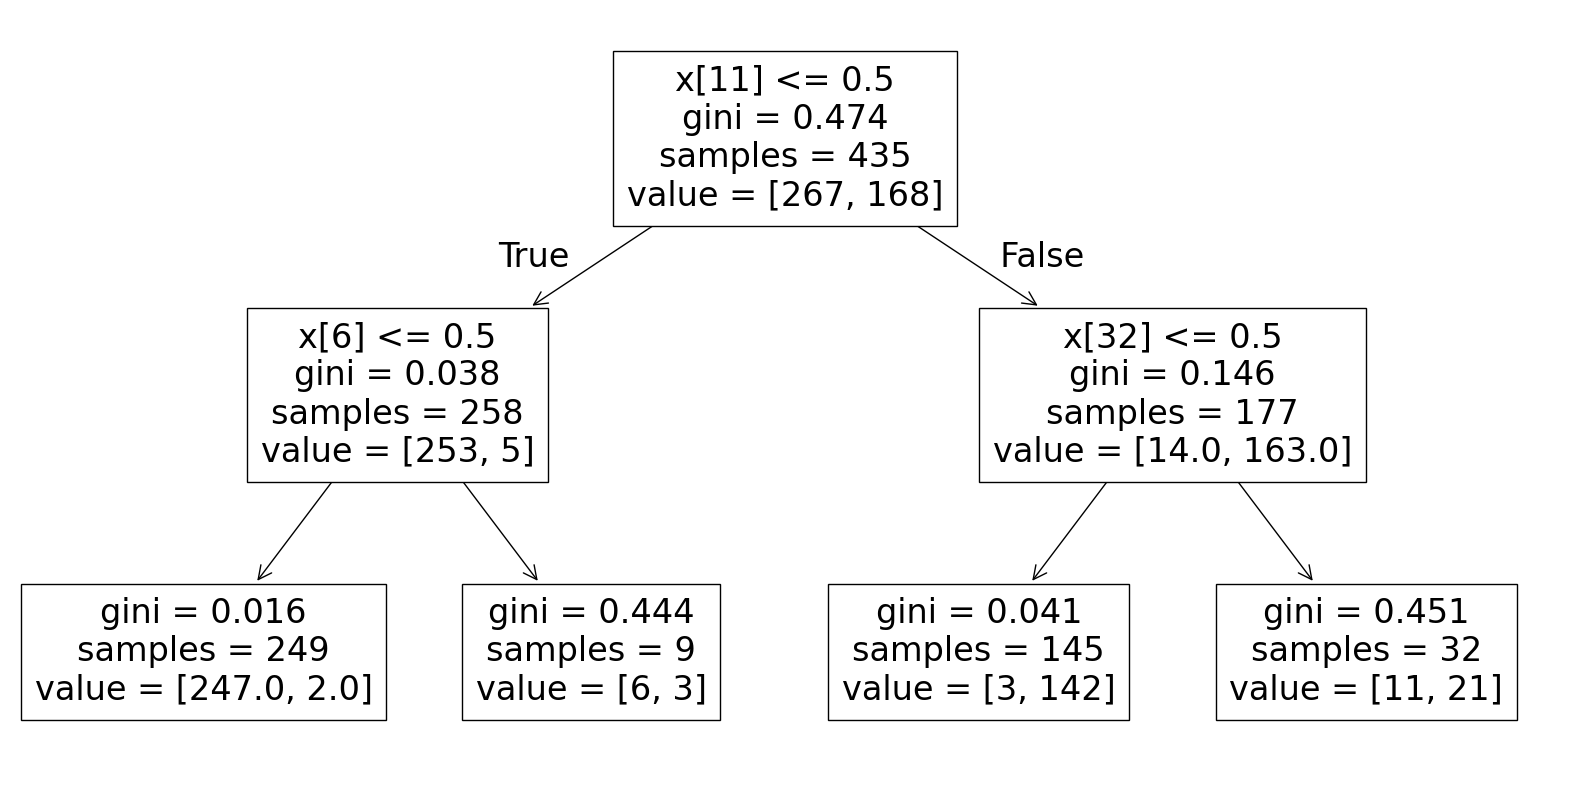

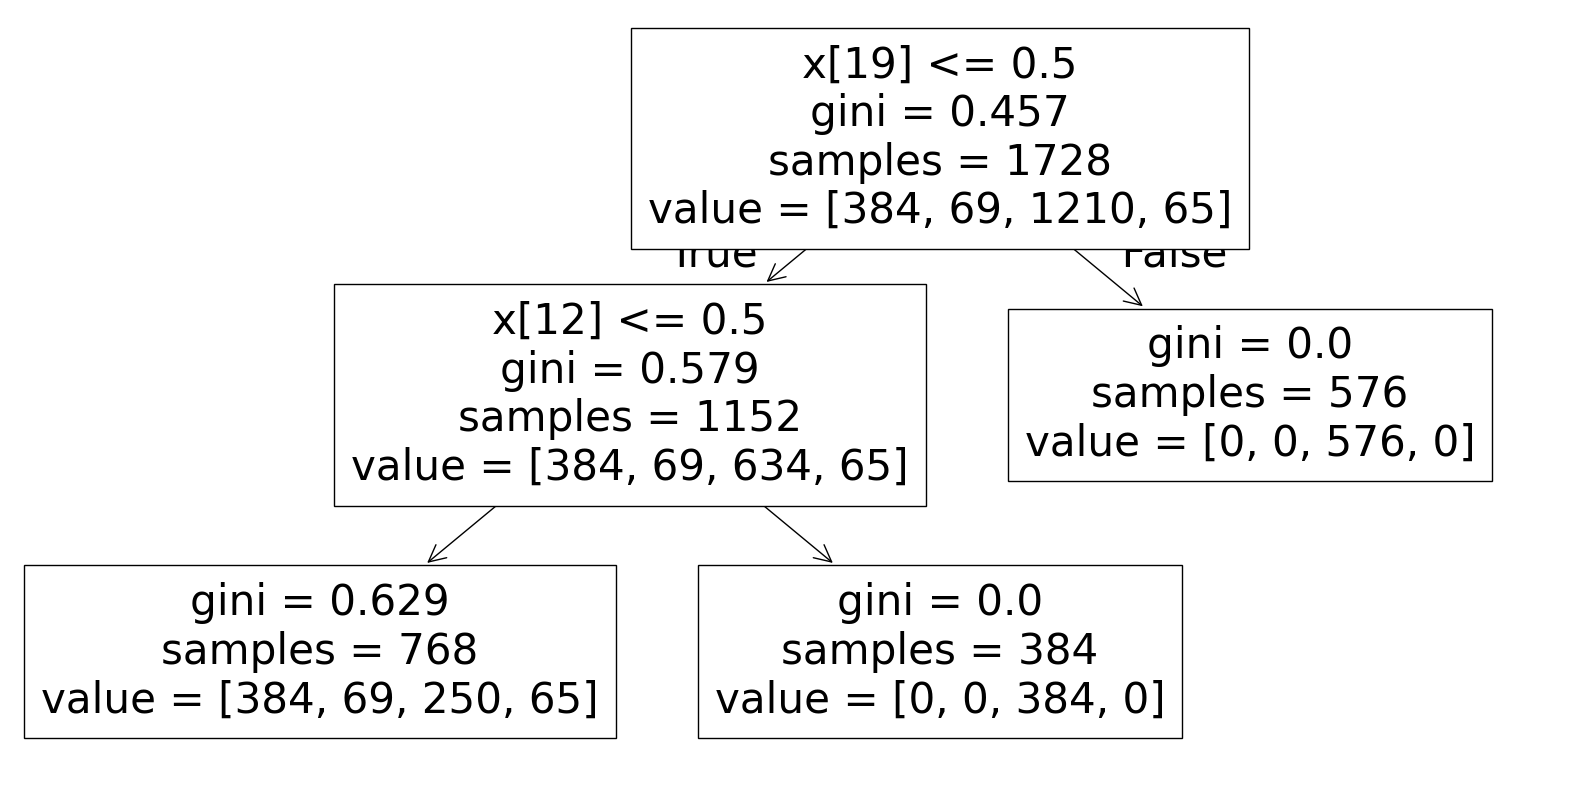

Max_depth=2 tree voting feature importances: 
                                     Feature  Importance
11                    physician-fee-freeze_y    0.958920
32            synfuels-corporation-cutback_y    0.030749
6        adoption-of-the-budget-resolution_?    0.010330
0                      handicapped-infants_?    0.000000
36                  superfund-right-to-sue_?    0.000000
27                             immigration_?    0.000000
28                             immigration_n    0.000000
29                             immigration_y    0.000000
30            synfuels-corporation-cutback_?    0.000000
31            synfuels-corporation-cutback_n    0.000000
33                      education-spending_?    0.000000
34                      education-spending_n    0.000000
35                      education-spending_y    0.000000
38                  superfund-right-to-sue_y    0.000000
37                  superfund-right-to-sue_n    0.000000
25                              mx-missile

In [213]:
# Print induced trees for the voting and car data sets

# Set up voting data
voting, meta = arff.loadarff('voting_with_missing.arff')
voting_df = pd.DataFrame(voting)
for feature in voting_df.columns:
    voting_df[feature] = voting_df[feature].str.decode('utf-8') 
X_voting = pd.get_dummies(voting_df.drop(columns="Class"))
y_voting = voting_df["Class"]

# Set up cars data
cars, meta = arff.loadarff("cars.arff")
cars_df = pd.DataFrame(cars)
for feature in cars_df.columns:
    cars_df[feature] = cars_df[feature].str.decode('utf-8') 
X_cars = pd.get_dummies(cars_df.drop(columns="class"))
y_cars = cars_df["class"]


# Print full trees
votingDTC = DecisionTreeClassifier()
votingDTC.fit(X_voting, y_voting)
carsDTC = DecisionTreeClassifier()
carsDTC.fit(X_cars, y_cars)
plt.figure(figsize=(20, 10))
plot_tree(votingDTC)
plt.figure(figsize=(30, 10))
plot_tree(carsDTC)
plt.show()

# Print out feature importances
importances = votingDTC.feature_importances_
feature_names = X_voting.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("Full tree voting feature importances: ")
print(feature_importance_df)

importances = carsDTC.feature_importances_
feature_names = X_cars.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("\nFull tree cars feature importances: ")
print(feature_importance_df)

# Print trees with max_depth = 2
votingDTC = DecisionTreeClassifier(max_depth=2)
votingDTC.fit(X_voting, y_voting)
carsDTC = DecisionTreeClassifier(max_depth=2)
carsDTC.fit(X_cars, y_cars)
plt.figure(figsize=(20, 10))
plot_tree(votingDTC)
plt.figure(figsize=(20, 10))
plot_tree(carsDTC)
plt.show()

# Print out feature importances
importances = votingDTC.feature_importances_
feature_names = X_voting.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("Max_depth=2 tree voting feature importances: ")
print(feature_importance_df)

importances = carsDTC.feature_importances_
feature_names = X_cars.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("\nMax_depth=2 tree cars feature importances: ")
print(feature_importance_df)


#### Discussion 
Discuss what the Trees have learned on the 2 data sets (i.e. look at the induced trees and describe what "rules" they discovered). How do the important features you would think about correspond the the "feature_importances_"

**The two smaller trees learn the same initial rules as the induced trees do, that is they find the same splits but then do not continue to expand the tree like the fully induced trees. For the voting data, the small tree finds that those who say no to physician-fee-freeze are much more likely to identify as a democrat and in the cars data, the tree finds that if a car has low safety level or only has a capacity of 2 people, then the car is unacceptable.  Overall, the important features that I would expect to be highly influential in the car data matched my expectations while for the voting data I really didn't know what the best splits would be.  The voting data overall was a little harder to understand and only had splits on yes, no, and unknown, which made it difficult to predict feature importances.**

### 2.4 (5%) Other Parameters
- For either of the data sets above experiment and discuss using a different split criterion (Compare Entropy and Log-loss with Gini)

Test accuracy using gini criterion:  0.9419540229885056
Test accuracy using entropy criterion:  0.9408045977011493
Test accuracy using log_loss criterion:  0.9408045977011493


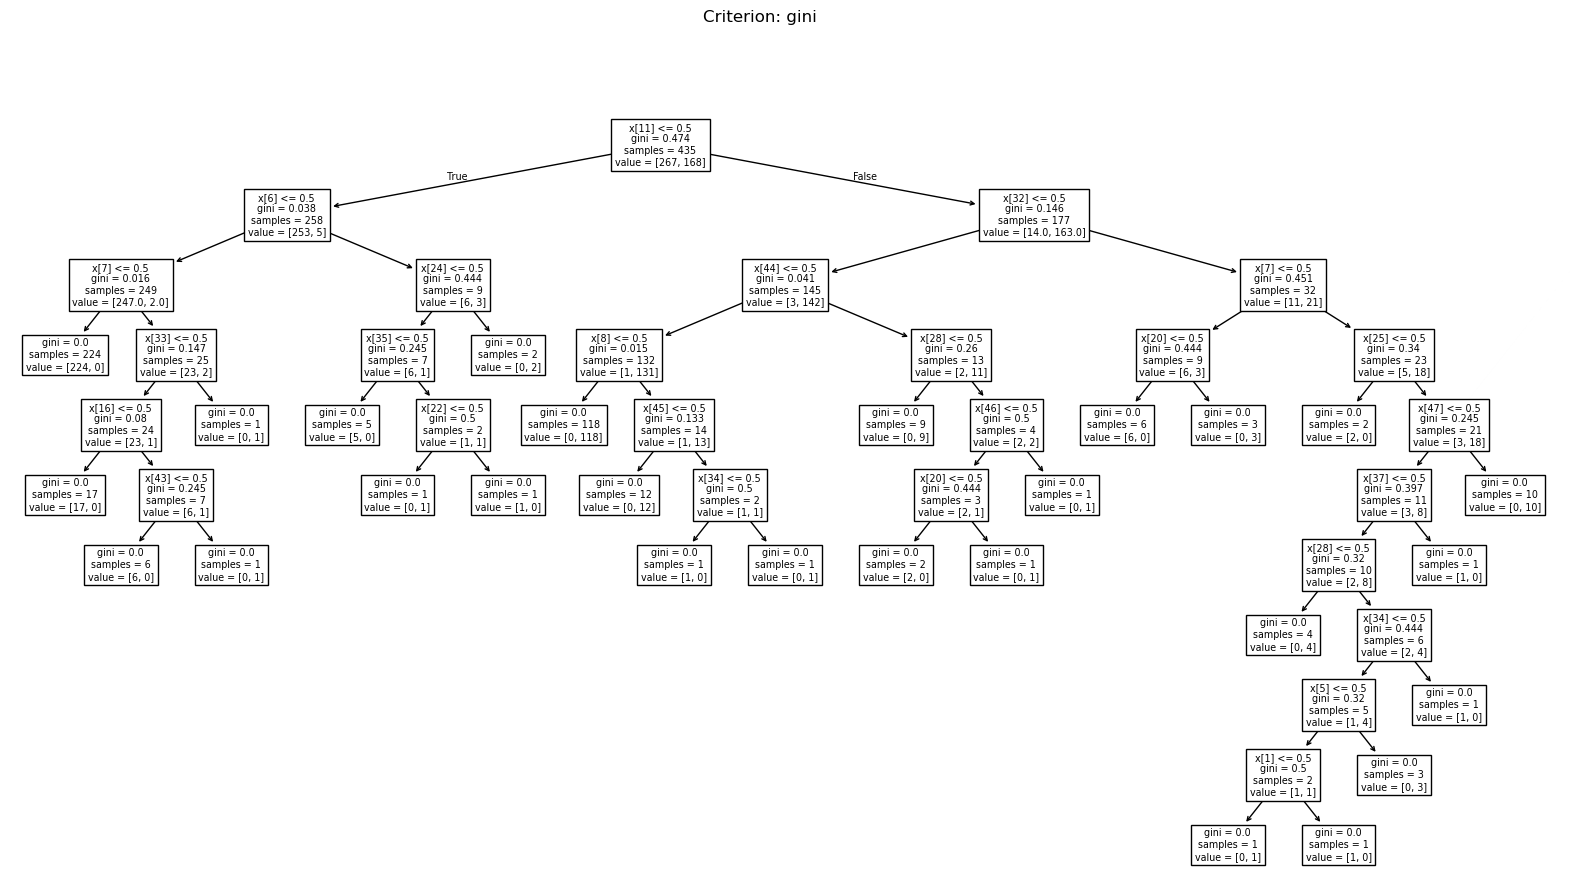

tree with criterion gini feature importances: 
                                     Feature  Importance
11                    physician-fee-freeze_y    0.827422
32            synfuels-corporation-cutback_y    0.026533
20                 anti-satellite-test-ban_y    0.025861
7        adoption-of-the-budget-resolution_n    0.014058
25                              mx-missile_n    0.013011
24                              mx-missile_?    0.011083
34                      education-spending_n    0.010021
28                             immigration_n    0.009300
6        adoption-of-the-budget-resolution_?    0.008914
33                      education-spending_?    0.008550
43                       duty-free-exports_n    0.008312
37                  superfund-right-to-sue_n    0.005642
1                      handicapped-infants_n    0.004849
22               aid-to-nicaraguan-contras_n    0.004849
45  export-administration-act-south-africa_?    0.004156
47  export-administration-act-south-afric

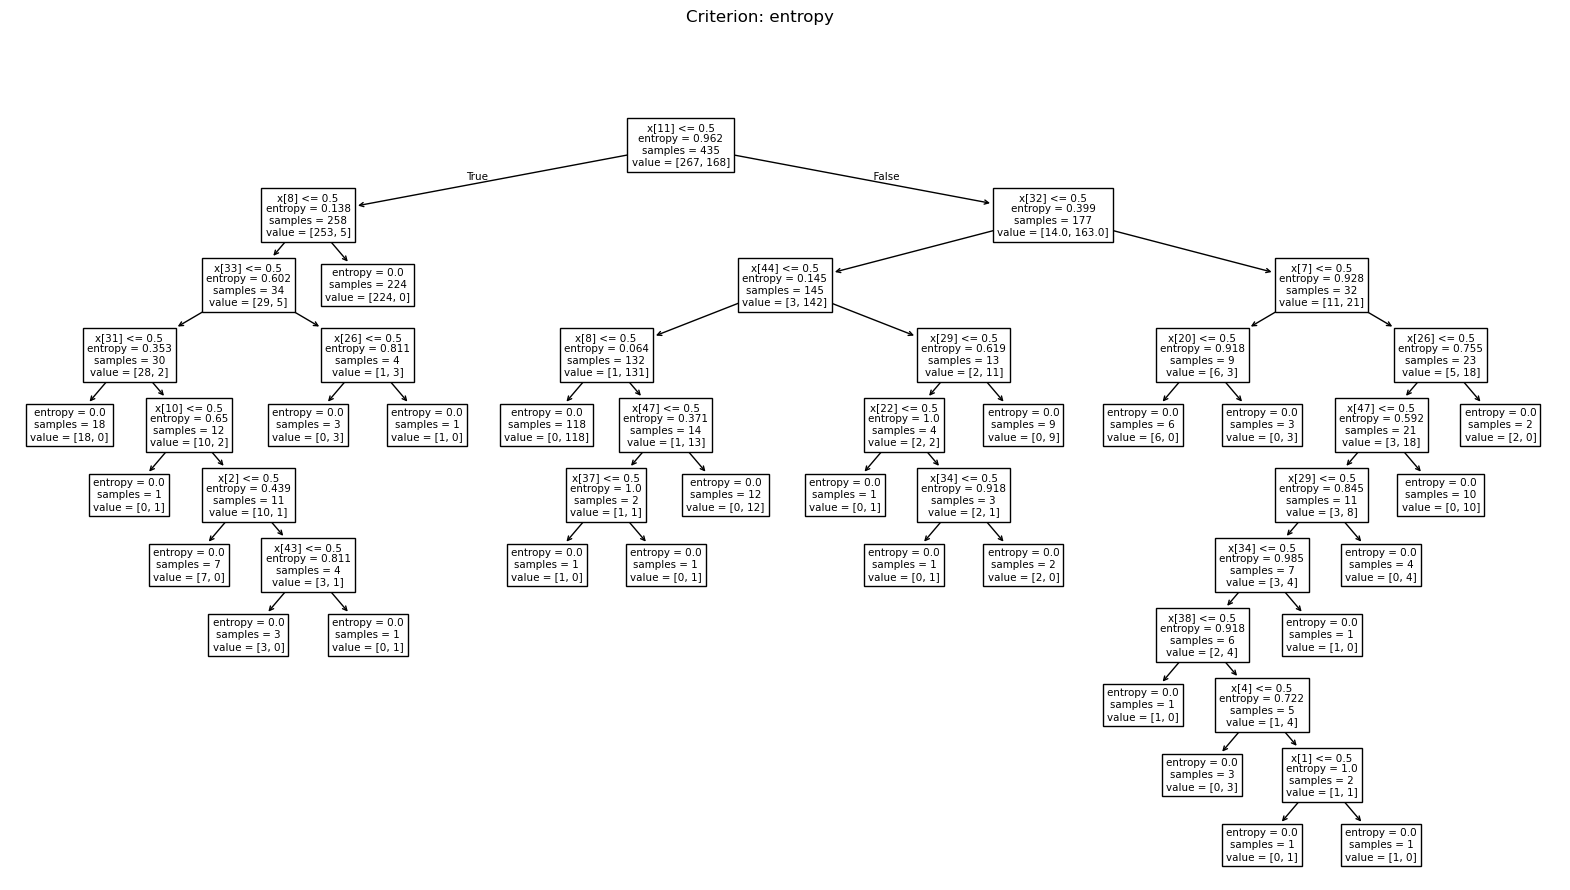

tree with criterion entropy feature importances: 
                                     Feature  Importance
11                    physician-fee-freeze_y    0.746275
32            synfuels-corporation-cutback_y    0.047408
8        adoption-of-the-budget-resolution_y    0.043935
20                 anti-satellite-test-ban_y    0.019743
26                              mx-missile_y    0.019574
33                      education-spending_?    0.015854
29                             immigration_y    0.015418
47  export-administration-act-south-africa_y    0.015106
44                       duty-free-exports_y    0.010832
34                      education-spending_n    0.009894
7        adoption-of-the-budget-resolution_n    0.009721
43                       duty-free-exports_n    0.007752
10                    physician-fee-freeze_n    0.007085
31            synfuels-corporation-cutback_n    0.006690
1                      handicapped-infants_n    0.004778
37                  superfund-right-to

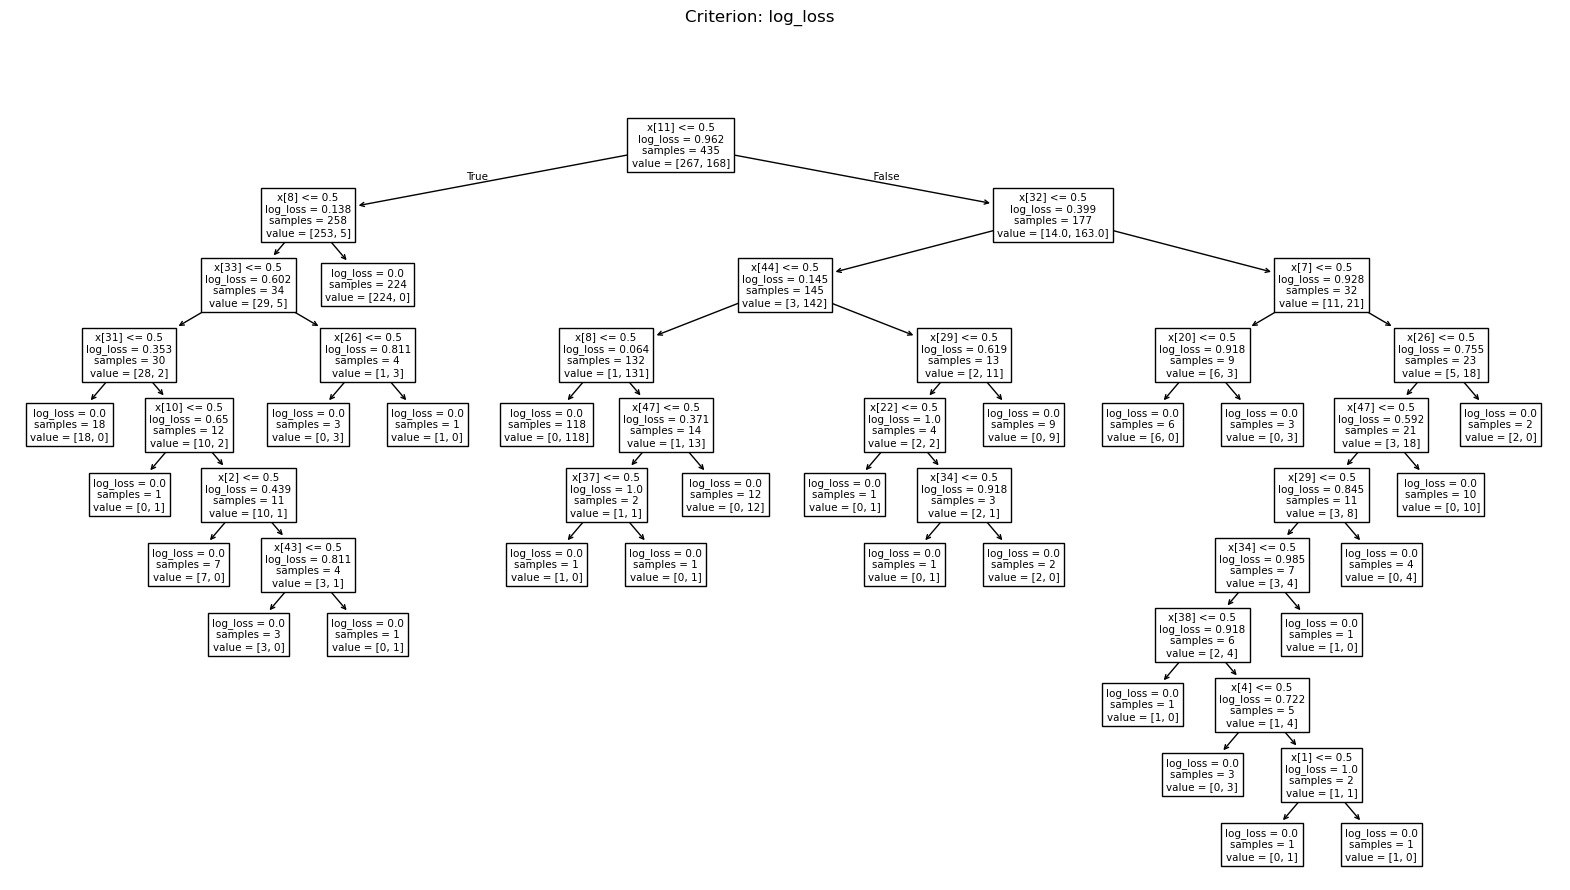

tree with criterion log_loss feature importances: 
                                     Feature  Importance
11                    physician-fee-freeze_y    0.746275
32            synfuels-corporation-cutback_y    0.047408
8        adoption-of-the-budget-resolution_y    0.043935
20                 anti-satellite-test-ban_y    0.019743
26                              mx-missile_y    0.019574
33                      education-spending_?    0.015854
29                             immigration_y    0.015418
47  export-administration-act-south-africa_y    0.015106
44                       duty-free-exports_y    0.010832
34                      education-spending_n    0.009894
7        adoption-of-the-budget-resolution_n    0.009721
43                       duty-free-exports_n    0.007752
10                    physician-fee-freeze_n    0.007085
31            synfuels-corporation-cutback_n    0.006690
1                      handicapped-infants_n    0.004778
37                  superfund-right-t

In [216]:
# Experiment with criterion parameter
# Set up voting data
voting, meta = arff.loadarff("voting_with_missing.arff")
voting_df = pd.DataFrame(voting)
for feature in voting_df.columns:
    voting_df[feature] = voting_df[feature].str.decode('utf-8') 
X_voting = pd.get_dummies(voting_df.drop(columns="Class"))
y_voting = voting_df["Class"]

# Optionally get accuracies averaged over 20 seeds
criterions = ["gini", "entropy", "log_loss"]
for criterion in criterions:
    accuracy = []
    for i in range(20):
        X_train_voting, X_test_voting, y_train_voting, y_test_voting = train_test_split(X_voting, y_voting, test_size=0.2, random_state=i)
        votingDTC = DecisionTreeClassifier(criterion=criterion, random_state=42)
        votingDTC.fit(X_train_voting, y_train_voting)
        accuracy.append(votingDTC.score(X_test_voting, y_test_voting))
    print(f"Test accuracy using {criterion} criterion: ", np.mean(accuracy))

# Print out trees and feature importances
for criterion in criterions:
    votingDTC = DecisionTreeClassifier(criterion=criterion, random_state=42)
    votingDTC.fit(X_voting, y_voting)
    plt.figure(figsize=(20, 10))
    plt.suptitle(f"Criterion: {criterion}")
    plot_tree(votingDTC)
    plt.show()

    # Print out feature importances
    importances = votingDTC.feature_importances_
    feature_names = X_voting.columns
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    print(f"tree with criterion {criterion} feature importances: ")
    print(feature_importance_df)

    

#### Discussion
How does using different split criteria (entropy, log-loss, and gini) affect accuracy, tree structure, and feature importance?

**For the voting data, using entropy and log-loss on the split criteria had the same effect, resulting in the same test accuracy, tree structure, and feature importance.  This differed slightly from using gini as the split criteria in a few different ways.  When using entropy or log-loss on the split criteria, the final test accuracy of the model was just a hair lower, the feature importance was spread over more atrributes and less dense on the first attribute, and the tree structure was a little different, with the main difference being that after the first split to the left, they had the next split on "adoption-of-the-budget-resolution_y" while the model using gini split on "immigration_?"**

## 3 Overfit Avoidance with Decision Trees  

Above, you found typical training and test set scores for the Cars data set when the tree is induced as far as it can go (until classes are pure or there are no more data or attributes to split on).  This usually leads to great training set scores but can potentially overfit and get lower accuracy on the test set.  You will now experiment with methods which can help avoid overfit and which could lead to better test set accuracy (though training set accuracy may decrease).  

### 3.1 Smaller and Simpler Trees (20%) 
- tree_: [Read about](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html#sphx-glr-auto-examples-tree-plot-unveil-tree-structure-py) the tree_ attribute with its sub attributes and methods allowing you to interact with your learned tree.  You don't have to do any specific task for this part.
- Use an 80/20 train/test split for all experiments in this part and induce (learn/fit) the full tree for Cars.
- For the fully induced tree print out
    - Training set accuracy
    - Test set accuracy
    - Total number of nodes (clf.tree_.node_count)
    - Maximum tree depth (clf.tree_.max_depth)
- Experiment with the following parameters which lead to smaller and/or simpler trees which can help with overfit.  Try a few different values of each parameter and compare their train and test set accuracies and number of nodes and depth with the fully induced tree.  If you are not sure how parameters are actually working, print some trees to see their effect.  Due to the simplicity of the Cars data set you may not see as great of accuracy improvements as you would for cases where overfit is more prominent.  
    - min_samples_leaf
    - min_samples_split
    - min_impurity_decrease
- Try these parameters also, but note that they could lead to underfit
    - max_depth
    - max_leaf_nodes
    - max_features

In [204]:
# Explore different overfit parameters
# Set up data
cars, meta = arff.loadarff("cars.arff")
cars_df = pd.DataFrame(cars)
for feature in cars_df.columns:
    cars_df[feature] = cars_df[feature].str.decode('utf-8') 
X_cars = pd.get_dummies(cars_df.drop(columns="class"))
y_cars = cars_df["class"]
X_train_cars, X_test_cars, y_train_cars, y_test_cars = train_test_split(X_cars, y_cars, test_size=0.2, random_state=42)

def get_stats(classifiers, X_train, X_test, y_train, y_test):
    rows = []
    for clf in classifiers:
        rows.append({
            "train_acc": clf.score(X_train, y_train),
            "test_acc": clf.score(X_test, y_test),
            "num_nodes": clf.tree_.node_count,
            "max_depth": clf.tree_.max_depth
        })

    results_df = pd.DataFrame(rows, index=[str(clf) for clf in classifiers])
    display(results_df)

classifiers = []
# Show full tree statistics for comparison

# Test over min_samples_leaf, min_samples_split, min_impurity_decrease, max_depth, max_leaf_nodes, max_features
for max_depth in [None]: #[None, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]:
    for max_leaf_nodes in [None]: #[None, 2, 3, 4, 5, 6, 7]:
        for max_features in [None]: #[None, "sqrt", "log2"]:
            for min_samples_leaf in [1, 2]: #[1, 2, 3, 5, 7, 10]:
                for min_samples_split in [2, 3]:
                    for min_impurity_decrease in [0.0, 0.0007, 0.0009, 0.001]:
                        carsDTC = DecisionTreeClassifier(max_depth=max_depth, max_leaf_nodes=max_leaf_nodes, 
                                                        max_features=max_features, min_samples_leaf=min_samples_leaf,
                                                        min_samples_split=min_samples_split, min_impurity_decrease=min_impurity_decrease, random_state=42)
                        carsDTC.fit(X_train_cars, y_train_cars)
                        classifiers.append(carsDTC)

get_stats(classifiers, X_train_cars, X_test_cars, y_train_cars, y_test_cars)



,train_acc,test_acc,num_nodes,max_depth
DecisionTreeClassifier(random_state=42),1.000000,0.956647,171,13
"DecisionTreeClassifier(min_impurity_decrease=0.0007, random_state=42)",0.986975,0.962428,107,12
"DecisionTreeClassifier(min_impurity_decrease=0.0009, random_state=42)",0.986975,0.962428,107,12
"DecisionTreeClassifier(min_impurity_decrease=0.001, random_state=42)",0.983357,0.956647,97,12
"DecisionTreeClassifier(min_samples_split=3, random_state=42)",0.994935,0.965318,157,12
"DecisionTreeClassifier(min_impurity_decrease=0.0007, min_samples_split=3,\n random_state=42)",0.986975,0.962428,107,12
"DecisionTreeClassifier(min_impurity_decrease=0.0009, min_samples_split=3,\n random_state=42)",0.986975,0.962428,107,12
"DecisionTreeClassifier(min_impurity_decrease=0.001, min_samples_split=3,\n random_state=42)",0.983357,0.956647,97,12
"DecisionTreeClassifier(min_samples_leaf=2, random_state=42)",0.989146,0.968208,149,12
"DecisionTreeClassifier(min_impurity_decrease=0.0007, min_samples_leaf=2,\n random_state=42)",0.984805,0.950867,101,12


#### Discussion
How did the methods used above help avoid overfit? How do you know? How did they affect accuracy (training and test) and tree structure? Which parameters helped the most with each dataset? How do you know?

**To test my model with varying parameters, I created a function that would take a list of models and return the resulting statistics of each. I created a parameter search to test whatever parameter combination. When adjusting the min_impurity_decrease parameter, the trees would become more shallow and in the case where min_impurity_decrease was between 0.0007 and 0.0008, the test accuracy would increase from 95.66% to 96.24%.  When adjusting min_samples_leaf, the tree become slightly more shallow and did not split into as many leaves. With min_samples_leaf=2 I saw an increase of test_acc to 96.82%. For min_samples_split I similarly saw that less nodes would split into leaves.  For the variations I tried of this hyperparameter, none improved the original model except for with min_samples_split=3 in which accuracy improved to 96.5%.  Overall with adjusting these three hyperparameters, the best model was with min_samples_leaf=2 and the others as the default values or with min_samples_leaf=2 and min_samples_split=3 with min_impurity_decrease set as its default. In addition, testing with adjustments to max_depth, max_leaf_nodes, and max_features all did not help the overfitting of the base model.**

### 3.2 (10%) Tree Reduction
Another approach to avoiding overfit is using pruning to reduce fully induced trees.  Induce the tree fully for Cars (no simplifying parameters such as max_depth).  Prune by setting the [ccp_alpha](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html#sphx-glr-auto-examples-tree-plot-cost-complexity-pruning-py) parameter to a positive value. This parameter controls how aggressive the pruning is. Try some small values (e.g. ,001, ,005, etc.) and try to find and report the value which works the best.  Make a table with at least 5 ccp_alpha values and for each value include
- Training set accuracy (you chooses the size of the train/test split)
- Test set accuracy
- Total number of nodes (clf.tree_.node_count)
- Maximum tree depth (clf.tree_.max_depth)

In [205]:
# Pruning
# Set up data
cars, meta = arff.loadarff("cars.arff")
cars_df = pd.DataFrame(cars)
for feature in cars_df.columns:
    cars_df[feature] = cars_df[feature].str.decode('utf-8') 
X_cars = pd.get_dummies(cars_df.drop(columns="class"))
y_cars = cars_df["class"]
X_train_cars, X_test_cars, y_train_cars, y_test_cars = train_test_split(X_cars, y_cars, test_size=0.2, random_state=42)

# Set up models
classifiers = []
for alpha in range(0, 10): # Test alphas from 0 to 0.01
    carsDTC = DecisionTreeClassifier(ccp_alpha=alpha/1000, random_state=42)
    carsDTC.fit(X_train_cars, y_train_cars)
    classifiers.append(carsDTC)

get_stats(classifiers, X_train_cars, X_test_cars, y_train_cars, y_test_cars)

,train_acc,test_acc,num_nodes,max_depth
DecisionTreeClassifier(random_state=42),1.000000,0.956647,171,13
"DecisionTreeClassifier(ccp_alpha=0.001, random_state=42)",0.986975,0.947977,107,12
"DecisionTreeClassifier(ccp_alpha=0.002, random_state=42)",0.976845,0.962428,83,12
"DecisionTreeClassifier(ccp_alpha=0.003, random_state=42)",0.959479,0.947977,61,10
"DecisionTreeClassifier(ccp_alpha=0.004, random_state=42)",0.937048,0.947977,43,9
"DecisionTreeClassifier(ccp_alpha=0.005, random_state=42)",0.926194,0.930636,35,8
"DecisionTreeClassifier(ccp_alpha=0.006, random_state=42)",0.926194,0.930636,35,8
"DecisionTreeClassifier(ccp_alpha=0.007, random_state=42)",0.920405,0.924855,33,8
"DecisionTreeClassifier(ccp_alpha=0.008, random_state=42)",0.906657,0.921965,29,8
"DecisionTreeClassifier(ccp_alpha=0.009, random_state=42)",0.883502,0.890173,25,8


#### Discussion
How did the pruning parameter ccp_alpha affect accuracy and tree structure? How does that compare to the methods above?

**Pruning by adjusting the parameter ccp_alpha generally improved the model's test accuracy and then made it worse, with the best value for ccp_alpha being 0.002, achieving a final test_acc of 96.24%. Overall, the tree depth decreased as the value for ccp_alpha increased.  This final accuracy is comparable to the improvement seen by adjusting the parameters above, although it is slightly less, with this model achieving 96.24% test_acc and the best model above achieving 96.82% test_acc.**

## 4. Decision Tree Regression
### 4.1 (15%) Learn a real-world regression data set of your choice (not already used in this or previous labs)
- Report tree statistics (# of nodes, # of leaf nodes, max depth)
- Report MAE on the training and test set (you choose the size of the train/test split)
- Report the DT regressor score for the training and test set.  Note that for the DT regressor this score is the coefficient of determination. Google it if you are curious.

In [206]:
#Learn regression data set
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Predict the day's high temperature using the day's low temperature
weather = pd.read_csv("Summary_of_Weather.csv")
weather_df = pd.DataFrame(weather)
weather_df = weather_df.dropna(subset=['MinTemp', 'Precip', 'MaxTemp'])
X = pd.get_dummies(weather_df[['MinTemp', 'Precip']])
y = weather_df['MaxTemp']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
weatherDTR = DecisionTreeRegressor(max_depth=10)
weatherDTR.fit(X_train, y_train)
print("Tree Statistics:")
get_stats([weatherDTR], X_train, X_test, y_train, y_test)
print("Number of leaf nodes: ", weatherDTR.get_n_leaves())
print("MAE on training set: ", mean_absolute_error(y_train, weatherDTR.predict(X_train)))
print("MAE on test set: ", mean_absolute_error(y_test, weatherDTR.predict(X_test)))
print("DT regressor score for training set: ", r2_score(y_train, weatherDTR.predict(X_train)))
print("DT regressor score for test set: ", r2_score(y_test, weatherDTR.predict(X_test)))

# Example prediction
example_pred = weatherDTR.predict(X.iloc[[0]])
print(f"Example: With a MinTemp of {X["MinTemp"].loc[0]} and Precip of {weather_df["Precip"].loc[0]} the model predicts a MaxTemp of {example_pred.item()}")


/var/folders/82/ycqlmd_96r37f5nv81vxfq8m0000gn/T/ipykernel_33937/507051901.py:6: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather = pd.read_csv("Summary_of_Weather.csv")


Tree Statistics:


,train_acc,test_acc,num_nodes,max_depth
DecisionTreeRegressor(max_depth=10),0.837748,0.836347,715,10


Number of leaf nodes:  358
MAE on training set:  2.562003447228008
MAE on test set:  2.581451624318923
DT regressor score for training set:  0.837747731259449
DT regressor score for test set:  0.8363465033336308
Example: With a MinTemp of 22.22222222 and Precip of 1.016 the model predicts a MaxTemp of 29.731501801724036


#### Discussion
Discuss your choice of dataset and regression feature. Also discuss the items listed above in 4.1

**I chose to use a dataset with weather conditions during World War II, found on kaggle. With this dataset, I fit my model to predict the daily max temperature (MaxTemp) using the daily min temperature (MinTemp) and the daily precipitation (Precip).  This resulted in an extremely large tree with depth 420, so I decided to add the max_depth=10 parameter to avoid too much overfitting. This resulted in a tree with 717 nodes, 359 leaf nodes, and an almost equal in and out of sample MAE of about 2.57. Similarly it resulted in an almost exactly equal train and test score of about 83%.**

## 5. (Optional 15% extra credit) Code up your own C4.5 Decision Tree Learner 
Implement the C4.5 algorithm discussed in class and in the slides, NOT the CART algorithm.  Below is a scaffold you could use if you want. Requirements for this task:
- Your model should support the methods shown in the example scaffold below.
- Use standard information gain as your basic attribute evaluation metric.  Note that C4.5 would usually augment information gain with a mechanism to penalize statistically insignificant attribute splits to avoid overfit (e.g. early stopping, gain ratio, etc.), but you are not required to do that.
- Include the ability to handle unknown attributes by making "unknown" a new attribute value when needed.
- You do not need to handle real valued attributes.
- It is a good idea to use simple data set (like the pizza homework), which you can check by hand, to test each detailed step of your algorithm to make sure it works correctly. 
- Run your algorithm on the voting data set above with unknown attributes and compare your results with CART.

**Overall, my model performed almost identically to that of the CART model on the voting data, with CART achieving an average test accuracy of 94.19% over 20 seeds and my model achieving a test accuracy of 94.59% over 20 seeds.  This initially surprised me because I thought that my function would be less than ideal, but since I am using the exact formula used in the C4.5 function, it makes sense that the results are good.  The hardest part about the implementation was figuring out the best way to create the tree.  Ultimately, I settled for using a node class that kept track of important attributes for the node that would help with the prediction of new points.**

In [207]:
from sklearn.base import BaseEstimator, ClassifierMixin

class DTClassifier(BaseEstimator,ClassifierMixin):

    def __init__(self,counts=None):
        """ Initialize class with chosen hyperparameters.
        Args:
        Optional Args (Args we think will make your life easier):
            counts: A list of Ints that tell you how many types of each feature there are
        Example:
            DT  = DTClassifier()
            or
            DT = DTClassifier(count = [2,3,2,2])
            Dataset = 
            [[0,1,0,0],
            [1,2,1,1],
            [0,1,1,0],
            [1,2,0,1],
            [0,0,1,1]]

        """

    class Node:
        def __init__(self, num_instances, instance_splits, child_nodes, previous_feature_split, possible_features, split_feature, split_value, X_subset, y_subset):
            self.num_instances = num_instances
            self.instance_splits = instance_splits
            self.child_nodes = child_nodes
            self.previous_feature_split = previous_feature_split
            self.possible_features = possible_features
            self.split_feature = split_feature
            self.split_value = split_value
            self.X_subset = X_subset
            self.y_subset = y_subset
            self.prediction = y_subset.mode()[0]

    def calculate_entropy(self, node_num_instances, node_instance_splits):
        probs = node_instance_splits / node_num_instances
        probs = probs[probs > 0]
        return -np.sum(probs * np.log2(probs))

    
    def calculate_entropy_gain(self, node, feature):
        parent_entropy = self.calculate_entropy(node.num_instances, node.instance_splits)
        possible_child_values = node.X_subset[feature].unique()
        child_entropy = 0
        for child_value in possible_child_values:
            child_y = node.y_subset[node.X_subset[feature] == child_value]
            child_num_instances = len(child_y)
            child_instance_splits = child_y.value_counts().values
            child_entropy += (child_num_instances / node.num_instances) * self.calculate_entropy(child_num_instances, child_instance_splits)
        return parent_entropy - child_entropy

    def decide_split(self, node):
        # Calculates entropy gain for each feature and returns best feature
        possible_gains = {}
        for feature in node.possible_features:
            possible_gains[feature] = self.calculate_entropy_gain(node, feature)
        best_feature = max(possible_gains, key=possible_gains.get)
        return best_feature

    def build_tree(self, node):
        # Find best feature to split on and then create leaf nodes
        if len(node.possible_features) == 0 or node.num_instances == 0 or len(node.y_subset.unique()) == 1:
            return
        
        best_feature = self.decide_split(node)
        node.split_feature = best_feature

        for feat_val in node.X_subset[best_feature].unique():
            X_subset = node.X_subset[node.X_subset[best_feature] == feat_val]
            y_subset = node.y_subset[node.X_subset[best_feature] == feat_val]
            num_instances = len(X_subset)
            instance_splits = y_subset.value_counts().values
            possible_features = node.possible_features.copy()
            possible_features.remove(best_feature)

            # create child node
            child = self.Node(
                num_instances=num_instances,
                instance_splits=instance_splits,
                child_nodes=[],
                previous_feature_split=best_feature,
                possible_features=possible_features,
                split_feature=None,
                split_value=feat_val,           
                X_subset=X_subset,
                y_subset=y_subset
            )

            node.child_nodes.append(child)
            self.build_tree(child)

    def fit(self, X, y):
        """ Fit the data; Make the Decision tree

        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
            y (array-like): A 1D numpy array with the training targets

        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)

        """
        self.X = X
        self.y = y
        possible_features = list(X.columns)
        # Include ability to handle unknown data
        for feature in X.columns:
            if type(X[feature]) == str:
                X[feature] = X[feature].str.decode('utf-8') 
        # Need to create instance_splits
        instance_splits = y.value_counts().values
        self.start_node = self.Node(len(X), instance_splits, [], None, possible_features, None, None, X, y)
        self.build_tree(self.start_node)
        return self

    def predict(self, X):
        """ Predict all classes for a dataset X

        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets

        Returns:
            array, shape (n_samples,)
                Predicted target values per element in X.
        """
        predictions = []
        for _, new_point in X.iterrows():
            current_node = self.start_node
            while len(current_node.child_nodes) > 0:
                value = new_point[current_node.split_feature]
                next_node = None
                for child in current_node.child_nodes:
                    if getattr(child, 'split_value', None) == value:
                        next_node = child
                        break
                if next_node is None:
                    break
                current_node = next_node
            predictions.append(current_node.prediction)

        return np.array(predictions)


    def score(self, X, y):
        """ Return accuracy(Classification Acc) of model on a given dataset. Must implement own score function.

        Args:
            X (array-like): A 2D numpy array with data, excluding targets
            y (array-like): A 1D numpy array of the targets 
        """
        predictions = self.predict(X)
        score = np.mean(predictions==y)
        return score
    
# Optional Debugging Dataset - Pizza Homework
# pizza_dataset = np.array([[1,2,0],[0,0,0],[0,1,1],[1,1,1],[1,0,0],[1,0,1],[0,2,1],[1,0,0],[0,2,0]])
# pizza_labels = np.array([2,0,1,2,1,2,1,1,0])
# X = pd.DataFrame(pizza_dataset)
# y = pd.Series(pizza_labels)
# DTCModel = DTClassifier(counts=[2, 3, 2])
# DTCModel.fit(X, y)
# print(DTCModel.predict(X))


In [217]:
# Compare my method with CART

voting, meta = arff.loadarff("voting_with_missing.arff")
voting_df = pd.DataFrame(voting)
for feature in voting_df.columns:
    voting_df[feature] = voting_df[feature].str.decode('utf-8') 
X_voting = pd.get_dummies(voting_df.drop(columns="Class"))
y_voting = voting_df["Class"]

DTCModel_accs = []
DTC_CART_accs = []
for i in range(20):
    X_voting_train, X_voting_test, y_voting_train, y_voting_test = train_test_split(X_voting, y_voting, test_size=0.2, random_state = i)

    # My Method
    DTCModel = DTClassifier().fit(X_voting_train, y_voting_train)
    DTCModel_accs.append(DTCModel.score(X_voting_test, y_voting_test))

    #Cart
    DTC_CART = DecisionTreeClassifier(random_state=42).fit(X_voting_train, y_voting_train)
    DTC_CART_accs.append(DTC_CART.score(X_voting_test, y_voting_test))

print(f"DTCModel average score: {np.mean(DTCModel_accs)}")
print(f"DTC_CART average score: {np.mean(DTC_CART_accs)}")


DTCModel average score: 0.945977011494253
DTC_CART average score: 0.9419540229885056
